# Programa para Casa \#4 — Otimização Multidimensional
---
**Disciplina**: Cálculo Numérico Aplicado
**Professor**: Prof. Dr. Rafael Gabler Gontijo
**Aluno**: Estevão André
**Atividade**: Programa para Casa \#4
## Comparando os métodos do Aclive Máximo e dos Gradientes Conjugados
Aqui serão implementados e comparados ambos os métodos de otimização multidimensional sem restrições:
1. método do **Aclive Máximo** (*Steepest Ascent*);
2. método dos **Gradientes Conjugados de Fletcher-Reeves**.
Os dois métodos serão empregados na maximização da mesma função objetivo e utilizarão o mesmo procedimento de busca unidimensional baseado em interpolação quadrática de três pontos.

In [56]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

## 1. Enunciado do problema

Deseja-se implementar e comparar dois métodos de otimização multidimensional sem restrições:

* Aclive Máximo;
* Gradientes Conjugados de Fletcher–Reeves.

A função objetivo a ser maximizada é

$$f(x,y)=2xy+2x-x^2-2y^2.$$

O ponto de máximo analítico da função é

$$
(x^\ast,y^\ast)=(2,1),
$$

para o qual

$$
f(x^\ast,y^\ast)=2.
$$

No método do Aclive Máximo, a direção de busca em cada iteração será definida pelo gradiente da função:

$$
\mathbf{p}_k=\nabla f(\mathbf{x}_k).
$$

No método dos Gradientes Conjugados de Fletcher–Reeves, a direção de busca será atualizada por


$$
\mathbf{p}_{k+1}=\nabla f_{k+1}+\beta_k\mathbf{p}_k,
$$

em que

$$
\beta_k=
\frac{\left|\nabla f_{k+1}\right|^2}
{\left|\nabla f_k\right|^2}.
$$

Em ambos os métodos, o comprimento do passo (h) será determinado por uma busca unidimensional baseada em interpolação quadrática de três pontos. Caso a parábola interpoladora seja degenerada, deverá ser adotado como passo o melhor valor entre os três pontos utilizados na interpolação.

O programa deverá solicitar ao usuário o ponto inicial

$$
(x_0,y_0)
$$

e executar os dois métodos a partir desse mesmo ponto.

Durante cada iteração, deverão ser apresentados:

* número da iteração;
* coordenadas atuais (x) e (y);
* valor da função (f(x,y));
* passo (h);
* erro definido pelo módulo do gradiente:

$$
\text{erro}=\left|\nabla f(x,y)\right|.
$$

Os resultados deverão ser armazenados nos seguintes arquivos:

* `output1.dat`: histórico do método do Aclive Máximo;
* `output2.dat`: histórico do método dos Gradientes Conjugados;
* `function.dat`: amostras de (x), (y) e (f(x,y)) para a construção das curvas de nível.

Cada linha dos arquivos de histórico deverá seguir o formato

```text
iter erro h x y dfx dfy
```

Ao final, deverão ser apresentadas as curvas de nível da função objetivo e as trajetórias produzidas pelos dois métodos.

Espera-se observar que o método do Aclive Máximo tende a apresentar uma trajetória em zigue-zague, enquanto o método dos Gradientes Conjugados de Fletcher–Reeves tende a seguir um caminho mais direto em direção ao ponto ótimo.

Também deverá ser analisado o efeito do ponto inicial sobre a trajetória e a eficiência de cada método.


## 2. Busca unidimensional por interpolação quadrática

Em cada iteração dos métodos de otimização multidimensional, será definida uma direção de busca $\mathbf{p}_k$. O problema multidimensional será então transformado em um problema unidimensional por meio da parametrização

$$
\mathbf{x}(h)=\mathbf{x}_k+h\mathbf{p}_k.
$$

Dessa forma, define-se a função unidimensional

$$
g(h)=f\left(\mathbf{x}_k+h\mathbf{p}_k\right).
$$

O valor ótimo do passo $h$ será estimado por interpolação quadrática de três pontos. A partir dos pontos $h_0$, $h_1$ e $h_2$, calcula-se o vértice da parábola interpoladora por

$$
h_3=
\frac{
g(h_0)(h_1^2-h_2^2)
+g(h_1)(h_2^2-h_0^2)
+g(h_2)(h_0^2-h_1^2)
}{
2g(h_0)(h_1-h_2)
+2g(h_1)(h_2-h_0)
+2g(h_2)(h_0-h_1)
}.
$$

Como o problema consiste na maximização da função objetivo, o intervalo de busca será atualizado de forma a preservar a região que contém o maior valor de $g(h)$.

Caso o denominador da expressão seja aproximadamente nulo, a parábola será considerada degenerada. Nesse caso, será adotado como resultado o melhor valor entre os três pontos disponíveis.


In [57]:
err = 1e-8  # Erro para analisar convergências "ε"

def inter_quad(
        g,
        h0=0.0,
        h2=2.0,
        tol=err,
        max_iter=100,
):
    """
    Maximiza uma função g(h) por meio da interpolação quadrática.

    :param g: callable
        Função a ser maximizada

    :param h0: float
        Limite inferior inicial do intervalo de busca

    :param h2: float
        Limite superior inicial do intervalo de busca

    :param tol: float
        Tolerância usada no critério de parada

    :param max_iter: int
        Nº máximo de iterações permitidas

    :return:
    h_opt: float
        Valor estimado do passo ótimo.

    g_opt: float
        Valor da função g no passo ótimo.

    iterations: int
        Número de iterações realizadas.
    """

    # Garante que h0 seja o limite inferior
    if h0 > h2:
        h0, h2 = h2, h0

    if h0 == h2:
        raise ValueError("Os limites h0 e h2 devem ser diferentes.")

    # Ponto intermediário inicial
    h1 = (h0 + h2) / 2.0

    def next_h(v0, v1, v2):
        """
        Calcula o vértice da parábola que interpola
        os três pontos fornecidos.
        """

        f0 = g(v0)
        f1 = g(v1)
        f2 = g(v2)

        numerator = (
            f0 * (v1**2 - v2**2)
            + f1 * (v2**2 - v0**2)
            + f2 * (v0**2 - v1**2)
        )

        denominator = (
            2.0 * f0 * (v1 - v2)
            + 2.0 * f1 * (v2 - v0)
            + 2.0 * f2 * (v0 - v1)
        )

        # Parábola degenerada
        if abs(denominator) < 1e-15:
            return None

        candidate = numerator / denominator

        # Proteção contra NaN ou infinito
        if not np.isfinite(candidate):
            return None

        return float(candidate)

    iteration = 0

    while abs(h2 - h0) >= tol and iteration < max_iter:

        iteration += 1

        h3 = next_h(h0, h1, h2)

        # Caso a parábola seja degenerada, seleciona o melhor
        # entre os três pontos atuais
        if h3 is None:
            candidates = [
                (g(h0), h0),
                (g(h1), h1),
                (g(h2), h2),
            ]

            g_opt, h_opt = max(
                candidates,
                key=lambda item: item[0]
            )

            return h_opt, g_opt, iteration

        # Se o vértice estiver fora do intervalo, escolhe o
        # ponto médio do maior subintervalo
        if not h0 < h3 < h2:

            left_size = h1 - h0
            right_size = h2 - h1

            if left_size >= right_size:
                h3 = (h0 + h1) / 2.0
            else:
                h3 = (h1 + h2) / 2.0

        f1 = g(h1)
        f3 = g(h3)

        # Evita a repetição indefinida do mesmo ponto
        if abs(h3 - h1) < tol:

            if f3 > f1:
                return h3, f3, iteration

            return h1, f1, iteration

        # Atualização do intervalo para um problema de maximização
        if h3 > h1:

            if f3 > f1:
                # O novo ponto é melhor e está à direita
                h0 = h1
                h1 = h3

            else:
                # O novo ponto é pior e está à direita
                h2 = h3

        else:

            if f3 > f1:
                # O novo ponto é melhor e está à esquerda
                h2 = h1
                h1 = h3

            else:
                # O novo ponto é pior e está à esquerda
                h0 = h3

    # Seleciona o melhor dos três pontos restantes
    candidates = [
        (g(h0), h0),
        (g(h1), h1),
        (g(h2), h2),
    ]

    g_opt, h_opt = max(
        candidates,
        key=lambda item: item[0]
    )

    return h_opt, g_opt, iteration

# 3. Método do Aclive Máximo *(Steepest Ascent)*

O método do Aclive Máximo busca o ponto de máximo caminhado em cada iteração na direção de maior crescimento local da função objetivo pelo gradiente.

Para um ponto atual

$$
\mathbf{x}_k=
\begin{bmatrix}
x_k,
y_k
\end{bmatrix},
$$

a direção de busca é definida pelo gradiente:
$$
\bf{p}_k=\nabla f(\mathbf{x}_k)
$$

Para a função objetivo

$$
f(x,y)=2xy+2x-x^2-2y^2,
$$

o gradiente é

\begin{bmatrix}
2y+2-2x,
2x-4y
\end{bmatrix}

Fixados o ponto atual $\mathbf{x}_k$ e a direção $\mathbf{p}_k$, define-se a função unidimensional, parametrização de $f$:

$$
g_k(h) = f\left(x_k + h\bf{p}_k\right)
$$

O passo ótimo $h_k$ é obtido pela função de interpolação quadrática. Em seguida, o ponto é atualizado por

$$
\mathbf{x}_k+h_k\mathbf{p}_k.
$$

O processo é repetido até que o módulo do gradiente seja menor que a tolerância estabelecida:

$$
\left|\nabla f(\mathbf{x}_k)\right|<\varepsilon.
$$

O módulo do gradiente também será utilizado como medida do erro:

$$
\text{erro}_k=
\left|\nabla f(\mathbf{x}_k)\right|.
$$

In [58]:
def func_obj(ponto) -> float:
    """
    Calcula a função objetivo:
        f(x, y) = 2xy + 2x - x² - 2y²

    :param ponto: array_like
        Vetor contendo as coordenadas [x, y].

    :return: float
        Valor da função objetivo no tal ponto.
    """
    x, y = ponto

    return 2.0 * x * y + 2.0 * x - x**2 - 2.0 * y**2

def gradiente(ponto) -> np.ndarray:
    """
    Calcula o gradiente da função objetivo:

        df/dx = 2y + 2 - 2x
        df/dy = 2x - 4y

    :param ponto: array_like
        Vetor contendo as coordenadas [x, y].

    :return: numpy.ndarray
        Vetor gradiente no ponto.
    """

    x, y = ponto

    dfdx = 2.0 * y + 2.0 - 2.0 * x
    dfdy = 2.0 * x - 4.0 * y

    return np.array([dfdx, dfdy], dtype=float)

#### *Construindo $g_k(h)$...*

In [59]:
def construir_g(ponto, direcao):
    """
    Constrói a função unidimensional:

        g(h) = f(ponto + h * direcao)

    A função retornada será utilizada pela interpolação quadrática.
    """

    def g(h):
        novo_ponto = ponto + h * direcao
        return func_obj(novo_ponto)

    return g

#### *Aclive máximo*

In [60]:
def aclive_maximo(
    ponto_inicial,
    tol_grad=1e-6,
    tol_linha=1e-10,
    max_iter=100,
    h0=0.0,
    h2=2.0,
    verbose=True
):
    """
    Maximiza a função objetivo pelo método do Aclive Máximo.

    :param ponto_inicial: array_like
        Coordenadas iniciais [x0, y0].

    :param tol_grad: float
        Tolerância para o módulo do gradiente.

    :param tol_linha: float
        Tolerância utilizada na interpolação quadrática.

    :param max_iter: int
        Número máximo de iterações do método.

    h0, h2 : float
        Limites iniciais da busca unidimensional.

    :param verbose: bool
        Controla a impressão das iterações na tela.

    :return:
    ponto : numpy.ndarray
        Ponto final calculado.

    valor_final : float
        Valor da função objetivo no ponto final.

    historico : numpy.ndarray
        Matriz com as colunas:

        iter, erro, h, x, y, dfdx, dfdy
    """

    ponto = np.array(ponto_inicial, dtype=float)

    grad = gradiente(ponto)
    erro = float(np.linalg.norm(grad))

    # A primeira linha representa o ponto inicial.
    # Como ainda não houve deslocamento, h = 0.
    historico = [
        [
            0,
            erro,
            0.0,
            ponto[0],
            ponto[1],
            grad[0],
            grad[1]
        ]
    ]

    if verbose:
        print(
            f"{'iter':>4} "
            f"{'x':>12} "
            f"{'y':>12} "
            f"{'f(x,y)':>12} "
            f"{'h':>12} "
            f"{'erro':>12}"
        )

        print(
            f"{0:4d} "
            f"{ponto[0]:12.6f} "
            f"{ponto[1]:12.6f} "
            f"{func_obj(ponto):12.6f} "
            f"{0.0:12.6f} "
            f"{erro:12.6e}"
        )

    for iteracao in range(1, max_iter + 1):

        # Critério de convergência
        if erro < tol_grad:
            break

        # No aclive máximo, a direção é o próprio gradiente
        direcao = grad.copy()

        # Constrói g(h) para o ponto e a direção atuais
        g = construir_g(ponto, direcao)

        # Encontra o passo ótimo pela interpolação quadrática
        h_opt, _, _ = inter_quad(
            g,
            h0=h0,
            h2=h2,
            tol=tol_linha,
            max_iter=100
        )

        # Atualiza o ponto
        ponto = ponto + h_opt * direcao

        # Calcula o gradiente e o erro no novo ponto
        grad = gradiente(ponto)
        erro = float(np.linalg.norm(grad))

        # Armazena os dados da iteração
        historico.append(
            [
                iteracao,
                erro,
                h_opt,
                ponto[0],
                ponto[1],
                grad[0],
                grad[1]
            ]
        )

        if verbose:
            print(
                f"{iteracao:4d} "
                f"{ponto[0]:12.6f} "
                f"{ponto[1]:12.6f} "
                f"{func_obj(ponto):12.6f} "
                f"{h_opt:12.6f} "
                f"{erro:12.6e}"
            )

    else:
        print(
            "Aviso: o número máximo de iterações foi atingido "
            "antes da convergência."
        )

    historico = np.array(historico, dtype=float)

    return ponto, func_obj(ponto), historico

#### *Testando...*

In [61]:
ponto_inicial = np.array([-2.0, 3.0])

ponto_aclive, valor_aclive, historico_aclive = aclive_maximo(
    ponto_inicial=ponto_inicial,
    tol_grad=1e-6,
    tol_linha=err,
    max_iter=100,
    h0=0.0,
    h2=2.0
)

# Valores esperados: Ponto final: [2. 1.]    Valor final:   2.000000000000

print()
print("Resultado do Aclive Máximo")
print(f"Ponto final: {ponto_aclive}")
print(f"Valor final: {valor_aclive:.12f}")
print(f"Quantidade de passos: {len(historico_aclive) - 1}")

iter            x            y       f(x,y)            h         erro
   0    -2.000000     3.000000   -38.000000     0.000000 2.000000e+01
   1     0.307692    -0.076923     0.461538     0.192308 1.538462e+00
   2     1.846154     1.076923     1.940828     1.250000 7.692308e-01
   3     1.934911     0.958580     1.997724     0.192308 5.917160e-02
   4     1.994083     1.002959     1.999912     1.250000 2.958580e-02
   5     1.997497     0.998407     1.999997     0.192308 2.275831e-03
   6     1.999772     1.000114     2.000000     1.250000 1.137915e-03
   7     1.999904     0.999939     2.000000     0.192308 8.753195e-05
   8     1.999991     1.000004     2.000000     1.250000 4.376597e-05
   9     1.999996     0.999998     2.000000     0.192308 3.366612e-06
  10     2.000000     1.000000     2.000000     1.250184 1.683546e-06
  11     2.000000     1.000000     2.000000     0.192275 1.290637e-07

Resultado do Aclive Máximo
Ponto final: [1.99999986 0.99999991]
Valor final: 2.0000000000

# 4. Método dos Gradientes Conjugados de Fletcher–Reeves

No método do Aclive Máximo, a direção de busca é substituída pelo gradiente da função a cada iteração. Esse procedimento pode produzir uma trajetória em zigue-zague, especialmente quando as curvas de nível da função são alongadas.

O método dos Gradientes Conjugados utiliza informações da direção anterior para construir uma nova direção de busca. A primeira direção é definida pelo gradiente no ponto inicial:

$$
\mathbf{p}_0=\nabla f(\mathbf{x}_0).
$$

Em cada iteração, o ponto é atualizado por

$$
\mathbf{x}_{k+1}
=
\mathbf{x}_k+h_k\mathbf{p}_k,
$$

em que o passo $h_k$ é calculado por meio da busca unidimensional aplicada à função

$$
g_k(h)
=
f\left(\mathbf{x}_k+h\mathbf{p}_k\right).
$$

Após o cálculo do novo ponto, determina-se o coeficiente de Fletcher–Reeves:

$$
\beta_k=
\frac{
\nabla f(\mathbf{x}_{k+1})\cdot\nabla f(\mathbf{x}_{k+1})
}{
\nabla f(\mathbf{x}_k)\cdot\nabla f(\mathbf{x}_k)
}.
$$

Esse coeficiente também pode ser escrito em termos das normas dos gradientes:

$$
\beta_k=
\frac{
\left\|\nabla f(\mathbf{x}_{k+1})\right\|^2
}{
\left\|\nabla f(\mathbf{x}_k)\right\|^2
}.
$$

A próxima direção de busca é então definida por

$$
\mathbf{p}_{k+1}
=
\nabla f(\mathbf{x}_{k+1})
+
\beta_k\mathbf{p}_k.
$$

O sinal positivo é empregado porque o problema consiste na maximização da função objetivo. A nova direção combina o gradiente atual com a direção utilizada na iteração anterior.

O processo é repetido até que

$$
\left\|\nabla f(\mathbf{x}_k)\right\|<\varepsilon.
$$

In [62]:
def fletcher_reeves(
    ponto_inicial,
    tol_grad=1e-6,
    tol_linha=1e-10,
    max_iter=100,
    h0=0.0,
    h2=2.0,
    verbose=True
):
    """
    Maximiza a função objetivo pelo método dos Gradientes
    Conjugados de Fletcher-Reeves.

    :param ponto_inicial: array_like
        Coordenadas iniciais [x0, y0].

    :param tol_grad: float
        Tolerância para o módulo do gradiente.

    :param tol_linha: float
        Tolerância utilizada na interpolação quadrática.

    :param max_iter: int
        Número máximo de iterações do método.

    :param h0: float
        Limite inferior inicial da busca unidimensional.

    :param h2: float
        Limite superior inicial da busca unidimensional.

    :param verbose: bool
        Controla a impressão das iterações na tela.

    :return:
    ponto : numpy.ndarray
        Ponto final calculado.

    valor_final : float
        Valor da função objetivo no ponto final.

    historico : numpy.ndarray
        Matriz com as colunas:

        iter, erro, h, x, y, dfdx, dfdy
    """

    ponto = np.array(ponto_inicial, dtype=float)

    # Gradiente no ponto inicial
    grad = gradiente(ponto)

    # A primeira direção de Fletcher-Reeves é o gradiente
    direcao = grad.copy()

    erro = float(np.linalg.norm(grad))

    # O ponto inicial é registrado com h = 0
    historico = [
        [
            0,
            erro,
            0.0,
            ponto[0],
            ponto[1],
            grad[0],
            grad[1]
        ]
    ]

    if verbose:
        print(
            f"{'iter':>4} "
            f"{'x':>12} "
            f"{'y':>12} "
            f"{'f(x,y)':>12} "
            f"{'h':>12} "
            f"{'erro':>12}"
        )

        print(
            f"{0:4d} "
            f"{ponto[0]:12.6f} "
            f"{ponto[1]:12.6f} "
            f"{func_obj(ponto):12.6f} "
            f"{0.0:12.6f} "
            f"{erro:12.6e}"
        )

    for iteracao in range(1, max_iter + 1):

        # Verifica a convergência antes de uma nova busca
        if erro < tol_grad:
            break

        # Constrói g(h) usando o ponto e a direção conjugada atuais
        g = construir_g(ponto, direcao)

        # Encontra o passo ótimo
        h_opt, _, _ = inter_quad(
            g,
            h0=h0,
            h2=h2,
            tol=tol_linha,
            max_iter=100
        )

        # Atualiza o ponto
        novo_ponto = ponto + h_opt * direcao

        # Calcula o gradiente no novo ponto
        novo_grad = gradiente(novo_ponto)
        novo_erro = float(np.linalg.norm(novo_grad))

        # Registra o novo ponto
        historico.append(
            [
                iteracao,
                novo_erro,
                h_opt,
                novo_ponto[0],
                novo_ponto[1],
                novo_grad[0],
                novo_grad[1]
            ]
        )

        if verbose:
            print(
                f"{iteracao:4d} "
                f"{novo_ponto[0]:12.6f} "
                f"{novo_ponto[1]:12.6f} "
                f"{func_obj(novo_ponto):12.6f} "
                f"{h_opt:12.6f} "
                f"{novo_erro:12.6e}"
            )

        # Se o novo ponto já satisfaz o critério de parada,
        # não é necessário calcular uma nova direção
        if novo_erro < tol_grad:
            ponto = novo_ponto
            grad = novo_grad
            erro = novo_erro
            break

        # Coeficiente de Fletcher-Reeves
        denominador = float(np.dot(grad, grad))

        if denominador < 1e-15:
            beta = 0.0
        else:
            beta = float(
                np.dot(novo_grad, novo_grad) / denominador
            )

        # Nova direção conjugada
        nova_direcao = novo_grad + beta * direcao

        # Atualiza as variáveis para a próxima iteração
        ponto = novo_ponto
        grad = novo_grad
        erro = novo_erro
        direcao = nova_direcao

    else:
        print(
            "Aviso: o número máximo de iterações foi atingido "
            "antes da convergência."
        )

    historico = np.array(historico, dtype=float)

    return ponto, func_obj(ponto), historico

#### *Testando...*

In [63]:
ponto_inicial = np.array([-2.0, 3.0])

ponto_fr, valor_fr, historico_fr = fletcher_reeves(
    ponto_inicial=ponto_inicial,
    tol_grad=1e-6,
    tol_linha=err,
    max_iter=100,
    h0=0.0,
    h2=2.0
)

# Valores esperados: Ponto final: [2. 1.]    Valor final:   2.000000000000

print()
print("Resultado de Fletcher-Reeves")
print(f"Ponto final: {ponto_fr}")
print(f"Valor final: {valor_fr:.12f}")
print(f"Quantidade de passos: {len(historico_fr) - 1}")

iter            x            y       f(x,y)            h         erro
   0    -2.000000     3.000000   -38.000000     0.000000 2.000000e+01
   1     0.307692    -0.076923     0.461538     0.192308 1.538462e+00
   2     2.000000     1.000000     2.000000     1.300000 9.272855e-15

Resultado de Fletcher-Reeves
Ponto final: [2. 1.]
Valor final: 2.000000000000
Quantidade de passos: 2


## 5. Armazenamento dos resultados e visualização das trajetórias

Os históricos produzidos pelos dois métodos serão armazenados em arquivos distintos:

* `output1.dat`: resultados do método do Aclive Máximo;
* `output2.dat`: resultados do método de Fletcher–Reeves;
* `function.dat`: amostras da função objetivo para a construção das curvas de nível.

Cada linha dos arquivos `output1.dat` e `output2.dat` seguirá o formato

```text
iter erro h x y dfx dfy
```

O arquivo `function.dat` armazenará os valores

```text
x y f
```

calculados sobre uma malha bidimensional.

Ao final, as trajetórias dos dois métodos serão sobrepostas às curvas de nível da função

$$
f(x,y)=2xy+2x-x^2-2y^2.
$$

O ponto inicial e o ponto ótimo analítico

$$
(x^\ast,y^\ast)=(2,1)
$$

também serão indicados no gráfico.


In [64]:
def salvar_historico(nome_arquivo, historico):
    """
    Salva o histórico de um método de otimização em um arquivo .dat.

    As colunas são:

        iter erro h x y dfx dfy

    :param nome_arquivo: str ou Path
        Nome do arquivo que será criado.

    :param historico: numpy.ndarray
        Matriz retornada pelo método de otimização.

    :return: Path
        Caminho do arquivo criado.
    """

    caminho = Path(nome_arquivo)

    formatos = [
        "%d",       # iteração
        "%.12e",    # erro
        "%.12e",    # h
        "%.12e",    # x
        "%.12e",    # y
        "%.12e",    # dfdx
        "%.12e",    # dfdy
    ]

    np.savetxt(
        caminho,
        historico,
        fmt=formatos,
        header="iter erro h x y dfx dfdy"
    )

    return caminho

In [65]:
def gerar_function_dat(
    historico_aclive,
    historico_fr,
    nome_arquivo="function.dat",
    numero_pontos=250
):
    """
    Gera amostras de x, y e f(x, y) para a construção
    das curvas de nível.

    O domínio é determinado automaticamente a partir das
    trajetórias dos dois métodos e do ponto ótimo analítico.

    :param historico_aclive: numpy.ndarray
        Histórico do método do Aclive Máximo.

    :param historico_fr: numpy.ndarray
        Histórico do método de Fletcher-Reeves.

    :param nome_arquivo: str ou Path
        Nome do arquivo de saída.

    :param numero_pontos: int
        Quantidade de pontos em cada direção da malha.

    :return:
        X, Y, Z : numpy.ndarray
            Matrizes da malha e dos valores da função.

        caminho : Path
            Caminho do arquivo criado.
    """

    # Colunas 3 e 4 dos históricos correspondem a x e y
    valores_x = np.concatenate(
        (
            historico_aclive[:, 3],
            historico_fr[:, 3],
            np.array([2.0])
        )
    )

    valores_y = np.concatenate(
        (
            historico_aclive[:, 4],
            historico_fr[:, 4],
            np.array([1.0])
        )
    )

    amplitude_x = np.ptp(valores_x)
    amplitude_y = np.ptp(valores_y)

    # Margem mínima para evitar um gráfico excessivamente fechado
    margem_x = max(0.5, 0.15 * amplitude_x)
    margem_y = max(0.5, 0.15 * amplitude_y)

    x_min = valores_x.min() - margem_x
    x_max = valores_x.max() + margem_x

    y_min = valores_y.min() - margem_y
    y_max = valores_y.max() + margem_y

    valores_malha_x = np.linspace(
        x_min,
        x_max,
        numero_pontos
    )

    valores_malha_y = np.linspace(
        y_min,
        y_max,
        numero_pontos
    )

    X, Y = np.meshgrid(
        valores_malha_x,
        valores_malha_y
    )

    # A função é calculada vetorialmente sobre toda a malha
    Z = (
        2.0 * X * Y
        + 2.0 * X
        - X**2
        - 2.0 * Y**2
    )

    dados_funcao = np.column_stack(
        (
            X.ravel(),
            Y.ravel(),
            Z.ravel()
        )
    )

    caminho = Path(nome_arquivo)

    np.savetxt(
        caminho,
        dados_funcao,
        fmt="%.12e",
        header="x y f"
    )

    return X, Y, Z, caminho

#### *Plotando as trajetórias...*

In [66]:
def plotar_trajetorias(
    arquivo_aclive="output1.dat",
    arquivo_fr="output2.dat",
    arquivo_funcao="function.dat",
    nome_imagem="trajetorias_ppc4.png",
    salvar_imagem=True
):
    """
    Gera o gráfico das curvas de nível da função objetivo
    com as trajetórias do Aclive Máximo e de Fletcher-Reeves.

    Os dados são carregados diretamente dos arquivos .dat.
    """

    dados_aclive = np.loadtxt(arquivo_aclive)
    dados_fr = np.loadtxt(arquivo_fr)
    dados_funcao = np.loadtxt(arquivo_funcao)

    # Históricos
    x_aclive = dados_aclive[:, 3]
    y_aclive = dados_aclive[:, 4]

    x_fr = dados_fr[:, 3]
    y_fr = dados_fr[:, 4]

    # Reconstrução da malha salva em function.dat
    valores_x = np.unique(dados_funcao[:, 0])
    valores_y = np.unique(dados_funcao[:, 1])

    numero_x = len(valores_x)
    numero_y = len(valores_y)

    X = dados_funcao[:, 0].reshape(numero_y, numero_x)
    Y = dados_funcao[:, 1].reshape(numero_y, numero_x)
    Z = dados_funcao[:, 2].reshape(numero_y, numero_x)

    fig, ax = plt.subplots(figsize=(10, 8))

    # Curvas preenchidas
    curvas_preenchidas = ax.contourf(
        X,
        Y,
        Z,
        levels=30,
        cmap="viridis",
        alpha=0.85
    )

    # Linhas de nível
    linhas_nivel = ax.contour(
        X,
        Y,
        Z,
        levels=20,
        colors="black",
        linewidths=0.5,
        alpha=0.55
    )

    ax.clabel(
        linhas_nivel,
        inline=True,
        fontsize=7,
        fmt="%.1f"
    )

    fig.colorbar(
        curvas_preenchidas,
        ax=ax,
        label=r"$f(x,y)$"
    )

    # Trajetória do Aclive Máximo
    ax.plot(
        x_aclive,
        y_aclive,
        marker="o",
        linestyle="-",
        linewidth=2.0,
        markersize=5,
        label="Aclive Máximo"
    )

    # Trajetória de Fletcher-Reeves
    ax.plot(
        x_fr,
        y_fr,
        marker="s",
        linestyle="--",
        linewidth=2.0,
        markersize=6,
        label="Fletcher–Reeves"
    )

    # Ponto inicial
    ax.scatter(
        x_aclive[0],
        y_aclive[0],
        marker="X",
        s=120,
        edgecolors="black",
        zorder=5,
        label="Ponto inicial"
    )

    # Ponto ótimo analítico
    ax.scatter(
        2.0,
        1.0,
        marker="*",
        s=220,
        edgecolors="black",
        zorder=6,
        label=r"Ótimo $(2,1)$"
    )

    # Rótulos das iterações do Aclive Máximo
    if len(x_aclive) <= 25:
        for indice, (x, y) in enumerate(
            zip(x_aclive, y_aclive)
        ):
            ax.annotate(
                str(indice),
                (x, y),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8
            )

    # Rótulos das iterações de Fletcher-Reeves
    if len(x_fr) <= 15:
        for indice, (x, y) in enumerate(
            zip(x_fr, y_fr)
        ):
            ax.annotate(
                f"FR{indice}",
                (x, y),
                xytext=(5, -13),
                textcoords="offset points",
                fontsize=8
            )

    ax.set_title(
        "Comparação das trajetórias dos métodos de otimização"
    )

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

    ax.grid(
        linestyle=":",
        linewidth=0.7,
        alpha=0.5
    )

    ax.legend()
    ax.set_aspect("equal", adjustable="box")

    fig.tight_layout()

    if salvar_imagem:
        fig.savefig(
            nome_imagem,
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()

    return fig, ax

### Célula Principal
Aqui é possível escolher o ponto inicial, comparar os métodos e ver todos os gráficos - em um só lugar ;)

Para ver claramente a diferença, tente o ponto (0,0)


MÉTODO DO ACLIVE MÁXIMO
iter            x            y       f(x,y)            h         erro
   0     0.000000     0.000000     0.000000     0.000000 2.000000e+00
   1     1.000000     0.000000     1.000000     0.500000 2.000000e+00
   2     1.000000     0.500000     1.500000     0.250000 1.000000e+00
   3     1.500000     0.500000     1.750000     0.500000 1.000000e+00
   4     1.500000     0.750000     1.875000     0.250000 5.000000e-01
   5     1.750000     0.750000     1.937500     0.500000 5.000000e-01
   6     1.750000     0.875000     1.968750     0.250000 2.500000e-01
   7     1.875000     0.875000     1.984375     0.500000 2.500000e-01
   8     1.875000     0.937500     1.992188     0.250000 1.250000e-01
   9     1.937500     0.937500     1.996094     0.500000 1.250000e-01
  10     1.937500     0.968750     1.998047     0.250000 6.250000e-02
  11     1.968750     0.968750     1.999023     0.500000 6.250000e-02
  12     1.968750     0.984375     1.999512     0.250000 3.125000

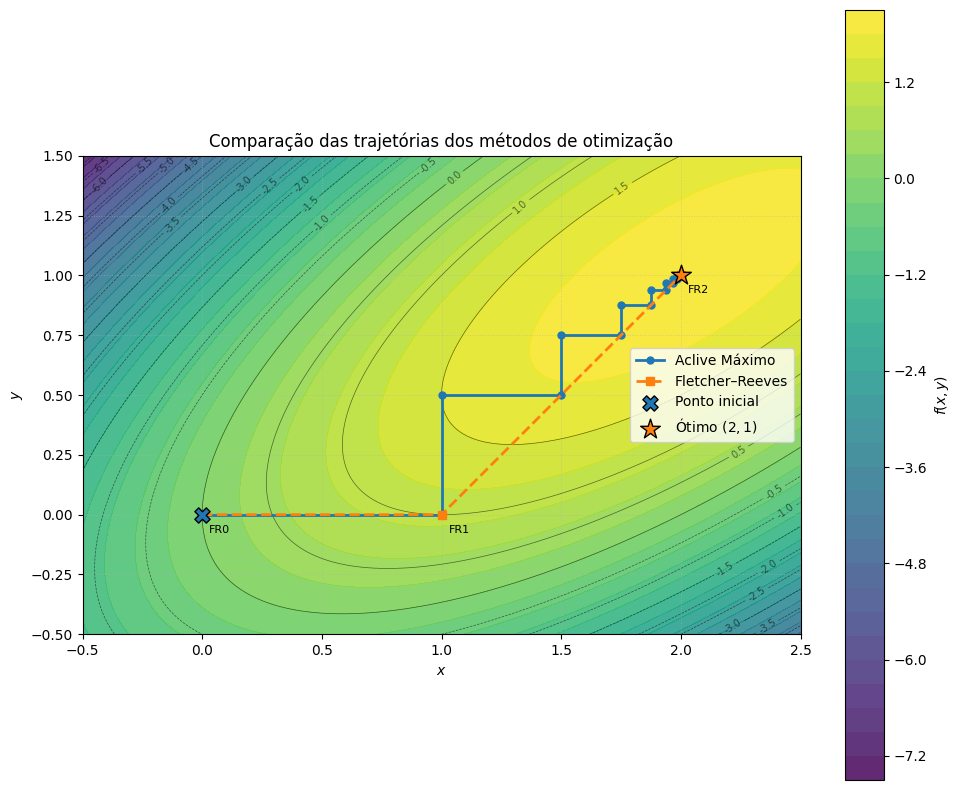

In [67]:
# Entrada do ponto inicial

x0 = float(
    input("Digite o valor inicial de x: ").replace(",", ".")
)

y0 = float(
    input("Digite o valor inicial de y: ").replace(",", ".")
)

ponto_inicial = np.array(
    [x0, y0],
    dtype=float
)


print("\n" + "=" * 70)
print("MÉTODO DO ACLIVE MÁXIMO")
print("=" * 70)

ponto_aclive, valor_aclive, historico_aclive = aclive_maximo(
    ponto_inicial=ponto_inicial,
    tol_grad=1e-6,
    tol_linha=err,
    max_iter=100,
    h0=0.0,
    h2=2.0,
    verbose=True
)


print("\n" + "=" * 70)
print("MÉTODO DE FLETCHER–REEVES")
print("=" * 70)

ponto_fr, valor_fr, historico_fr = fletcher_reeves(
    ponto_inicial=ponto_inicial,
    tol_grad=1e-6,
    tol_linha=err,
    max_iter=100,
    h0=0.0,
    h2=2.0,
    verbose=True
)


# Salvamento dos históricos

arquivo_aclive = salvar_historico(
    "output1.dat",
    historico_aclive
)

arquivo_fr = salvar_historico(
    "output2.dat",
    historico_fr
)


# Geração das amostras da função

X, Y, Z, arquivo_funcao = gerar_function_dat(
    historico_aclive=historico_aclive,
    historico_fr=historico_fr,
    nome_arquivo="function.dat",
    numero_pontos=250
)


# Resumo dos resultados

print("\n" + "=" * 70)
print("RESUMO DOS RESULTADOS")
print("=" * 70)

print("\nAclive Máximo")
print(f"Ponto final: {ponto_aclive}")
print(f"Valor final: {valor_aclive:.12f}")
print(f"Número de passos: {len(historico_aclive) - 1}")

print("\nFletcher–Reeves")
print(f"Ponto final: {ponto_fr}")
print(f"Valor final: {valor_fr:.12f}")
print(f"Número de passos: {len(historico_fr) - 1}")

print("\nArquivos gerados:")
print(f"- {arquivo_aclive.resolve()}")
print(f"- {arquivo_fr.resolve()}")
print(f"- {arquivo_funcao.resolve()}")


# Construção do gráfico comparativo

fig, ax = plotar_trajetorias(
    arquivo_aclive=arquivo_aclive,
    arquivo_fr=arquivo_fr,
    arquivo_funcao=arquivo_funcao,
    nome_imagem="trajetorias_ppc4.png",
    salvar_imagem=True
)